In [1]:
from itertools import product
from itertools import product
import logging
import os
import pickle
import sys


from multiprocessing import Pool

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.spatial import Delaunay

from eryn.ensemble import EnsembleSampler
from eryn.moves import DistributionGenerateRJ, StretchMove, GaussianMove
from eryn.prior import uniform_dist, log_uniform, ProbDistContainer
from eryn.state import State

import corner
from tqdm import trange

from local_utils import delaunaytor
from local_utils.moves import BinGaussRelMove

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)
plt.style.use("tableau-colorblind10")

In [7]:
d = delaunaytor.CPUDelaunayInterpolator()
d.triangulate(
    np.array([
        [0, 0, 0, 0],
        [0 ,1, 0, 0], 
        [1, 0, 0, 0],
        [0, 0, 1, 0],
    ]) 
)
d.num_events()

0.16666666666666666

In [2]:
to_read = np.load(f"1000_events/data.npz")
observed_events = to_read["observed_events"]
event_logpriors = np.log(to_read["event_logpriors"])
event_barycenters = to_read["event_barycenters"]
event_limits = to_read["event_limits"]
samples_per_event = to_read["samples_per_event"]
detected_injections = to_read["detected_injections"]
injection_priors = to_read["injection_priors"]
num_injections = to_read["num_injections"]

corners = 9 * np.array([
    [-1, -1],
    [-1, 1],
    [1, -1],
    [1, 1],
])

class SquareLogLikelihood(delaunaytor.DelaunayLogLikelihood):

    def __init__(self, corners, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.corners = corners
        
    def __call__(self, population_parameters):
        (tri_parameters, corner_weights) = population_parameters

        corner_weights = corner_weights.squeeze()
        
        triangulation_parameters = np.vstack([tri_parameters, np.c_[self.corners, corner_weights.T]])
        return super().__call__(triangulation_parameters)

log_like_fn = SquareLogLikelihood(
    corners=corners,
    events=observed_events,
    events_log_prior=event_logpriors,
    detected_injections=detected_injections,
    detected_injections_prior=injection_priors,
    num_events=event_barycenters.shape[0],
    num_samples=samples_per_event,
    num_injections=num_injections,
    minus_infinity=-1e300,
)

In [3]:
def make_valid_delaunay(event_points, injection_points, num_vertices, corners):
    
    points = np.vstack([
        event_points, 
        #injection_points
    ])
    if num_vertices > 3 + points.shape[0]:
        raise ValueError("That number of vertices breaks geometry")

    min_max_x = [np.min(points[:, 0]), np.max(points[:, 0])]
    min_max_y = [np.min(points[:, 1]), np.max(points[:, 1])]

    vertices = np.zeros((num_vertices + 4, 2))
    valid_vertices = 0
    vertices[:4] = corners

    c = 0
    while valid_vertices < num_vertices:
        vertices[valid_vertices + 4, 0] = np.random.uniform(*min_max_x)
        vertices[valid_vertices + 4, 1] = np.random.uniform(*min_max_y)
        
        this_tri = Delaunay(vertices[: 5 + valid_vertices])
        points_simplex = this_tri.find_simplex(points)
        event_simplex = points_simplex[: event_points.shape[0]]

        if (points_simplex != -1).all():
            valid_vertices += 1

        c += 1
        if c > 10_000:
            logger.debug("Arg, again!")
            vertices = np.zeros((num_vertices + 4, 2))
            vertices[:4] = corners
            valid_vertices = 0
            c = 0

    return vertices[4:]

In [4]:
nwalkers = 2
ntemps = 2

branch_names = ["tri", "corners"]
ndims = {"tri": 3, "corners": 4}
nleaves_min = {"tri": 4, "corners": 1}
nleaves_max = {"tri": 40, "corners": 1}

start_with_this_many = 6

priors = {
    "tri": {
        0: uniform_dist(
            corners[:, 0].min(), corners[:, 0].max()
        ),
        1: uniform_dist(
            corners[:, 1].min(), corners[:, 1].max()
        ),
        2: uniform_dist(-6, 9)
    },
    "corners": {
        d: uniform_dist(-6, 9) for d in range(ndims["corners"])
    }
}

coords = {}
inds = {}

for branch in branch_names:
    coords[branch] = np.zeros((ntemps, nwalkers, nleaves_max[branch], ndims[branch])) 
    inds[branch] = np.zeros((ntemps, nwalkers, nleaves_max[branch]), dtype=bool)
    
    for i in range(ndims[branch]):
        coords[branch][..., i] = priors[branch][i].rvs(size=(ntemps, nwalkers, nleaves_max[branch]))
        
    if branch == "tri":
        inds["tri"][:, :, :start_with_this_many] = True
    else:
        inds[branch][:, :, :] = True

for t, w in product(range(ntemps), range(nwalkers)):

    le_log = -np.inf
    for _ in trange(10_000):
        init_proposal = {
            "tri": np.c_[
            make_valid_delaunay(
                event_barycenters[:, :2],
                detected_injections[:, :2], 
                start_with_this_many,
                log_like_fn.corners
            ),  
            priors["tri"][2].rvs(start_with_this_many)
            ]
        } | {
            branch: np.array(
                [priors[branch][dim_indx].rvs() for dim_indx in range(ndims[branch])]
            ).squeeze()
            for branch in priors if branch != "tri"
        }
        
        le_log = log_like_fn([
            init_proposal[key] for key in ["tri", "corners"]
        ]) or -1e300

        if le_log > -1e300:
            break
    else:
        raise ValueError("Didn't work")

    print(t, w, le_log)
    for branch in init_proposal:
        coords[branch][
            t, w, : (
                start_with_this_many 
                if branch == "tri" else nleaves_max[branch]
            )
        ] = init_proposal[branch]
        

    print(le_log)

  0%|                                                                 | 0/10000 [00:00<?, ?it/s]


0 0 -307.0093222692508
-307.0093222692508


  0%|                                                                 | 0/10000 [00:00<?, ?it/s]


0 1 -1100.0802254162797
-1100.0802254162797


  0%|                                                       | 1/10000 [00:01<3:24:18,  1.23s/it]


1 0 -44.26852759883836
-44.26852759883836


  0%|                                                                 | 0/10000 [00:00<?, ?it/s]

1 1 -1112.9653485571644
-1112.9653485571644


  0%|                                                                     | 0/2 [00:00<?, ?it/s]/tmp/ipykernel_27131/1401975952.py:12: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  c = ax.scatter(


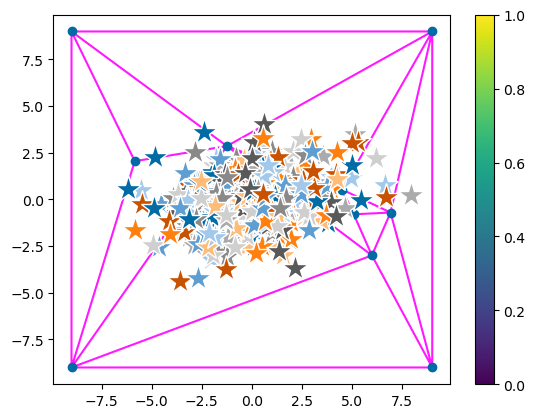

 50%|██████████████████████████████▌                              | 1/2 [00:00<00:00,  1.22it/s]

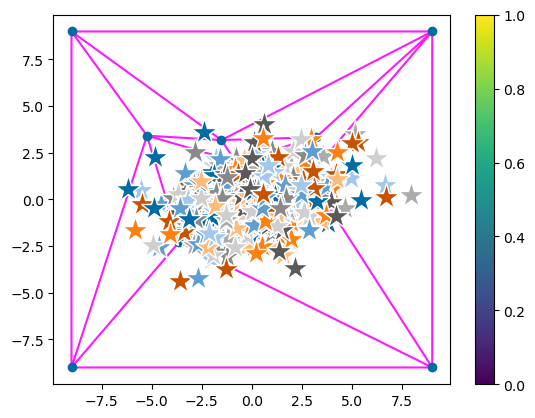

100%|█████████████████████████████████████████████████████████████| 2/2 [00:01<00:00,  1.28it/s]


In [5]:
for ind in trange(nwalkers):
    params = np.vstack([
        coords["tri"][0, ind, inds["tri"][0, ind], :-1],
        log_like_fn.corners
    ])

    tri = Delaunay(params)

    fig, ax = plt.subplots()
    ax.set_rasterized(True)

    c = ax.scatter(
        params[:, 0], params[:, 1], cmap="magma", zorder=100
    )

    ax.triplot(
        params[:, 0],
        params[:, 1],
        tri.simplices,
        color="fuchsia",
        ls="-",
        alpha=0.9,
    )
    
    
    for event_indx in range(event_barycenters.shape[0]):

        l = ax.plot(
            observed_events[event_indx * samples_per_event : (event_indx + 1) * samples_per_event, 0], 
            observed_events[event_indx * samples_per_event : (event_indx + 1) * samples_per_event, 1],
            ".",
            alpha=0.,
        )
        ax.plot(
            event_barycenters[event_indx, 0], 
            event_barycenters[event_indx, 1], 
            "*", color="white", markerfacecolor=l[0].get_color(), markersize=20, zorder=1000
        )

    
    fig.colorbar(c)
    plt.show()
    plt.close()

In [6]:
moves = [ 
        BinGaussRelMove(
            sigma_vertices=0.1,
            weights_scale=event_barycenters.shape[0],
            ind_leaf=ind_leaf,
            branch_name="tri",
        )
    for ind_leaf in range(nleaves_max["tri"])
] 

moves_ = [
    StretchMove(
        gibbs_sampling_setup=["corners"],
        live_dangerously=True
    )
]



prior_move = DistributionGenerateRJ(
    {key: ProbDistContainer(priors[key]) for key in priors},
    nleaves_min={key: val for key, val in nleaves_min.items()},
    nleaves_max={key: val for key, val in nleaves_max.items()},
)
rj_moves = [prior_move]

state = State(coords, inds=inds)

In [95]:
nburn = 500
nsteps = 100

with Pool(4) as pool:
    ensemble = EnsembleSampler(
        nwalkers,
        ndims,
        log_like_fn,
        priors,
        tempering_kwargs=dict(ntemps=ntemps),
        nbranches=len(branch_names),
        branch_names=branch_names,
        nleaves_max=nleaves_max,
        nleaves_min=nleaves_min,
        moves=moves,
        rj_moves=rj_moves,
        pool=pool,
    )

    last_sample = ensemble.run_mcmc(
        state, nsteps, burn=nburn, progress=True, thin_by=1
    )

 27%|█████████████████████████████████████████▎                                                                                                               | 135/500 [05:47<15:31,  2.55s/it]/home/rodrigo/git/p-pop-delaunay/local_utils/delaunaytor.py:191: RuntimeWarning: overflow encountered in exp
  maybe_infinity = np.exp(log_Nxi)
 61%|█████████████████████████████████████████████████████████████████████████████████████████████▋                                                           | 306/500 [12:06<06:31,  2.02s/it]/home/rodrigo/git/p-pop-delaunay/local_utils/delaunaytor.py:191: RuntimeWarning: overflow encountered in exp
  maybe_infinity = np.exp(log_Nxi)
100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [03:29<00:00,  2.09s/it]


[[13. 29.]
 [28. 26.]]


  0%|                                                                                                                                                                     | 0/2 [00:00<?, ?it/s]

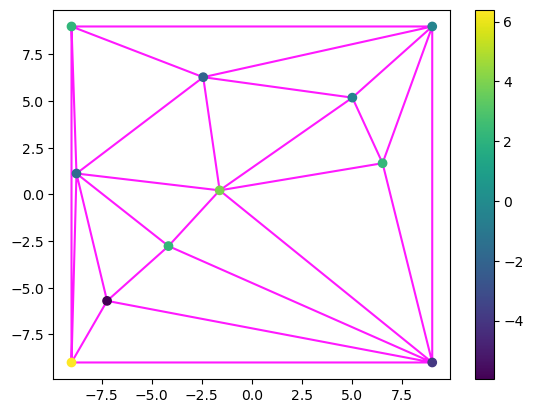

 50%|██████████████████████████████████████████████████████████████████████████████▌                                                                              | 1/2 [00:00<00:00,  7.55it/s]

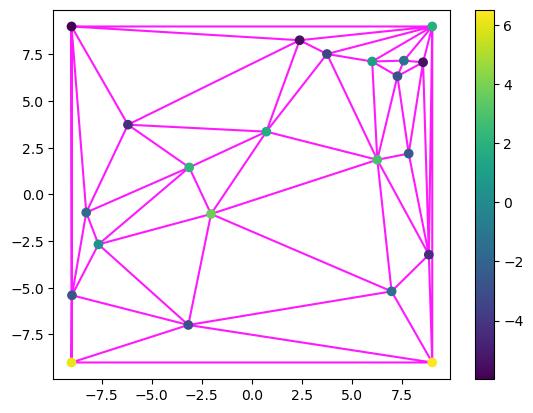

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:00<00:00,  8.28it/s]


In [96]:
print(ensemble.backend.rj_accepted)

for ind in trange(nwalkers):
    params = last_sample.branches["tri"].coords[0, ind, last_sample.branches["tri"].inds[0, ind, :]]

    tri = Delaunay(
        np.vstack([
            params[:, :-1],
            log_like_fn.corners,
        ])
    )

    fig, ax = plt.subplots()
    ax.set_rasterized(True)

    ax.triplot(
        tri.points[:, 0],
        tri.points[:, 1],
        tri.simplices,
        color="fuchsia",
        ls="-",
        alpha=0.9,
    )
    
    c = ax.scatter(
        tri.points[:, 0],
        tri.points[:, 1],
        c = np.hstack([
            params[:, -1], 
            last_sample.branches["corners"].coords[0, ind, 0]
        ])
    )
    
    fig.colorbar(c)
    plt.show()
    plt.close()

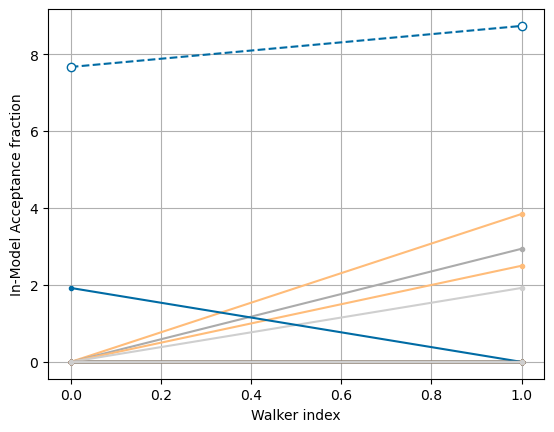

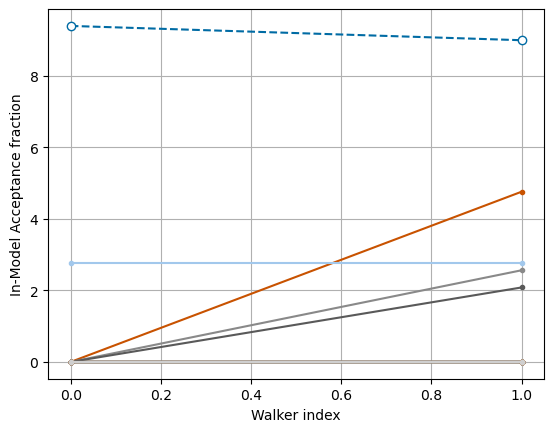

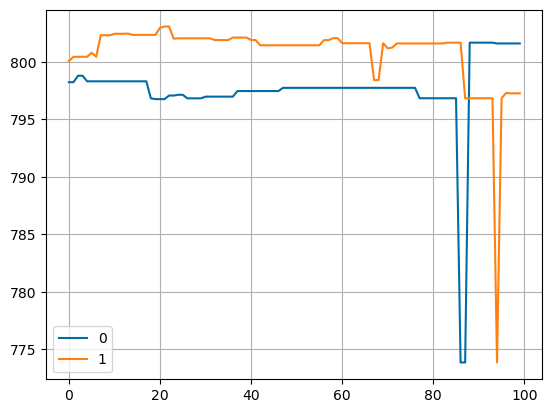

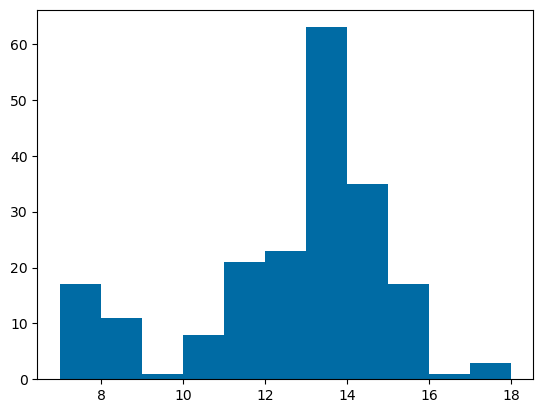

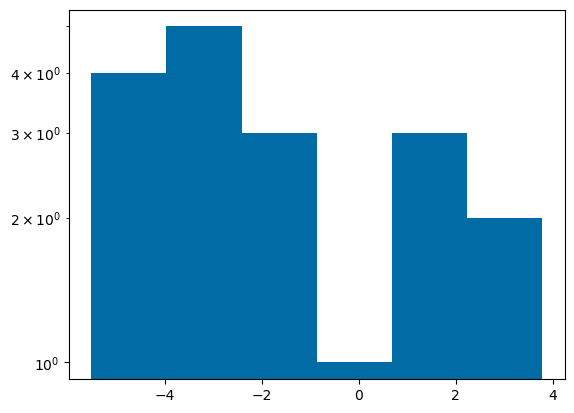

In [97]:
chain = ensemble.get_chain()
leaves = ensemble.get_nleaves()

for t in range(ntemps):
    fig, ax = plt.subplots()
    ax.set_rasterized(True)
    ax.set(
        xlabel="Walker index",
        ylabel="In-Model Acceptance fraction",
        yscale="linear",
        #yticks=np.arange(0, 105, 5),
    )
    ax.grid()
    for move in ensemble.moves:
        ax.plot(100 * move.acceptance_fraction[t], ".-")

    for move in (ensemble.rj_moves or []):
        ax.plot(100 * move.acceptance_fraction[t], "o--", markerfacecolor="white")
    plt.show()
    plt.close()

fig, ax = plt.subplots()
ax.set_rasterized(True)
ax.grid()
for w in range(nwalkers):
    ax.plot(ensemble.get_log_like()[:, 0, w], label=w)
ax.legend()
plt.show()
plt.close()

fig, ax = plt.subplots()
ax.set_rasterized(True)
ax.hist(leaves["tri"][:, 0].ravel(), bins="auto")
plt.show()
plt.close()

fig, ax = plt.subplots()
ax.set_rasterized(True)
ax.set(yscale="log")
ax.hist(params[:, -1], bins="auto")
plt.show()
plt.close()

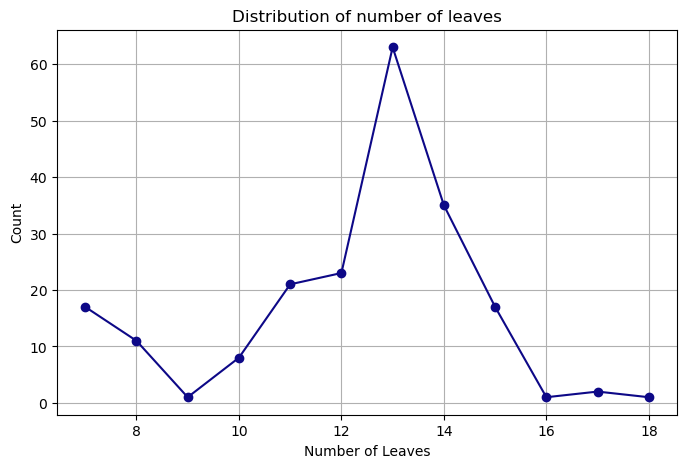

In [98]:
tri_sizes = np.array([
    ensemble.backend.inds["tri"][step, 0, walker].sum()
    for step, walker in product(range(nsteps), range(nwalkers))
])

fig, ax = plt.subplots(figsize=(8, 5))
ax.grid(which="both")
ax.set(
    yscale="linear",
    title="Distribution of number of leaves",
    xlabel="Number of Leaves",
    ylabel="Count"
)


NUM_COLORS = 1
cm = plt.get_cmap('plasma')
ax.set_prop_cycle(color=[cm(1.*i/NUM_COLORS) for i in range(NUM_COLORS)])

bins, counts = np.unique(tri_sizes, return_counts=True)
ax.plot(bins, counts, "o-")

In [99]:
from tqdm import tqdm

triangulations =  [
    ensemble.backend.chain["tri"][step, 0, walker][ensemble.backend.inds["tri"][step, 0, walker]]
    for step, walker in product(range(nsteps), range(nwalkers))
]

corner_weights = np.array(
    [
        ensemble.backend.chain["corners"][step, 0, walker]
        for step, walker in product(range(nsteps), range(nwalkers))
    ]
)

triangulations = [
    np.vstack([
        triangulations[ind],
        np.c_[corners, corner_weights[ind].T]
    ])
    for ind in range(len(triangulations))
]

In [100]:
def compute_num_events(triangulation_points):
    tri = delaunaytor.CPUDelaunayInterpolator()
    tri.triangulate(triangulation_points)
    weights_in_vertices = tri.weights[tri.triangulation.simplices]

    weight_diffs = np.c_[
        (weights_in_vertices[:, 1] - weights_in_vertices[:, 2]),
        (weights_in_vertices[:, 2] - weights_in_vertices[:, 0]),
        (weights_in_vertices[:, 0] - weights_in_vertices[:, 1]),
    ]
    bar_integral = (np.exp(weights_in_vertices) * weight_diffs).sum(axis=-1) / (
        -weight_diffs
    ).prod(axis=-1)

    return (2 * tri.volumes() * bar_integral).sum()

In [101]:
estimated_num_events = np.array([compute_num_events(tri) for tri in triangulations])

In [1]:
x_grid = np.linspace(-9, 9, 100)
y_grid = np.linspace(-9, 9, 100)
X, Y = np.meshgrid(x_grid, y_grid)
grid = np.c_[X.ravel(), Y.ravel()]

dx = x_grid[1] - x_grid[0]
dy = y_grid[1] - y_grid[0]

NameError: name 'np' is not defined

In [103]:
num_triangulations = 2_00
selected_tris = np.random.choice(len(triangulations), size=num_triangulations, replace=False)

log_rate = np.zeros((num_triangulations, grid.shape[0]))

for ind, tri_ind in enumerate(tqdm(selected_tris)):
    this_delo = delaunaytor.CPUDelaunayInterpolator()
    this_delo.triangulate(triangulations[tri_ind])
    log_rate[ind] = this_delo.interpolate(grid)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [00:00<00:00, 360.54it/s]


In [104]:
square_rate = log_rate.reshape(num_triangulations, y_grid.shape[0], x_grid.shape[0])

median = np.quantile(square_rate, 0.5, axis=0)
low = np.quantile(square_rate, 0.05, axis=0)
high = np.quantile(square_rate, 0.95, axis=0)

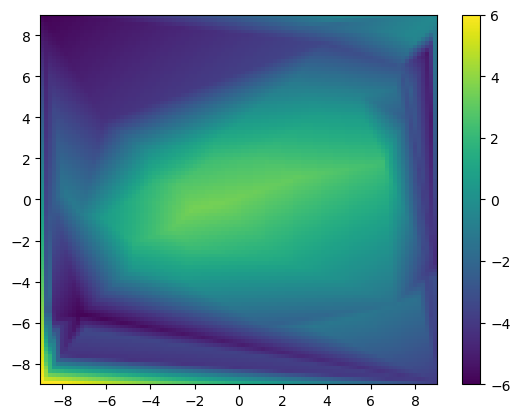

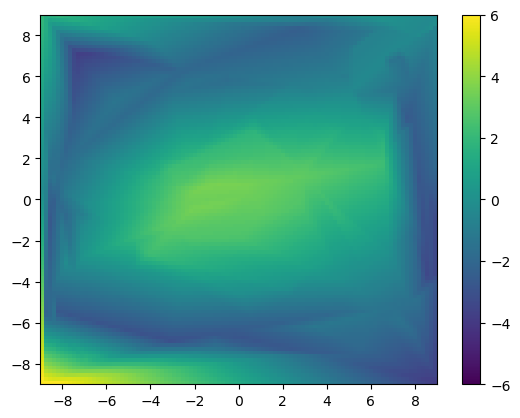

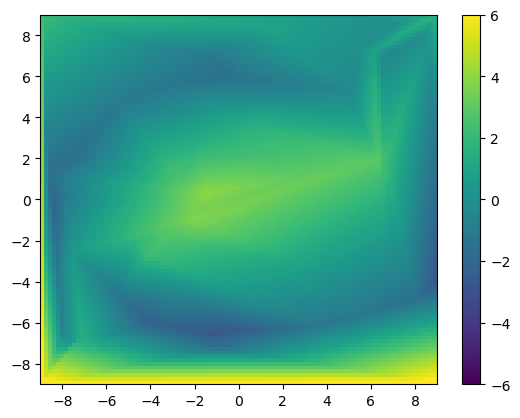

In [105]:
for data in [low, median, high]:
    fig, ax = plt.subplots()
    c = ax.pcolormesh(x_grid, y_grid, data[:-1, :-1], vmin=-6, vmax=6)
    fig.colorbar(c)
    plt.show()
    plt.close()

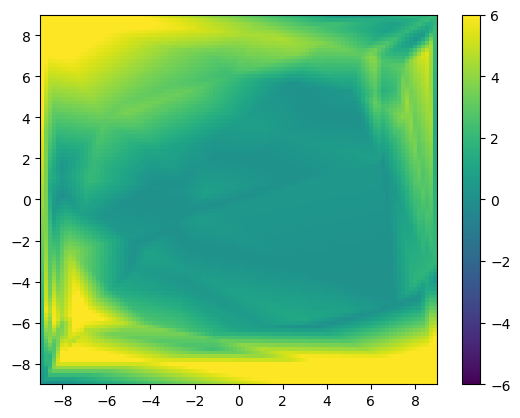

In [106]:
fig, ax = plt.subplots()
c = ax.pcolormesh(x_grid, y_grid, (high - low)[:-1, :-1], vmin=-6, vmax=6)
fig.colorbar(c)
plt.show()
plt.close()

In [107]:
from scipy import special

In [108]:
gt_distro = stats.multivariate_normal(np.zeros(2), np.array([[8, 2], [2, 3]]))
gt_num_events = 1_000

gt_samples = gt_distro.rvs(100_000)


x_bins = x_grid[0]-dx + dx * np.arange(2 + (x_grid[-1] - x_grid[0]) // dx)
y_bins = y_grid[0]-dy + dy * np.arange(2 + (y_grid[-1] - y_grid[0]) // dy)

x_pdf_gt = np.histogram(gt_samples[:, 0], bins=x_bins, density=True)[0]
y_pdf_gt = np.histogram(gt_samples[:, 1], bins=y_bins, density=True)[0]

x_rate_gt = x_pdf_gt * gt_num_events
y_rate_gt = y_pdf_gt * gt_num_events

In [109]:
num_triangulations = 200
selected_tris = np.random.choice(len(triangulations), size=num_triangulations, replace=False)

log10_dNdx = np.zeros((num_triangulations, x_grid.shape[0]))

for ind, tri_ind in enumerate(tqdm(selected_tris)):
    this_delo = delaunaytor.CPUDelaunayInterpolator()
    this_delo.triangulate(triangulations[tri_ind])
    log_rate = this_delo.interpolate(grid).reshape(y_grid.shape[0], x_grid.shape[0])
    log10_dNdx[ind] = (special.logsumexp(log_rate, axis=0) + np.log(y_grid[1] - y_grid[0])) / np.log(10)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [00:00<00:00, 387.09it/s]


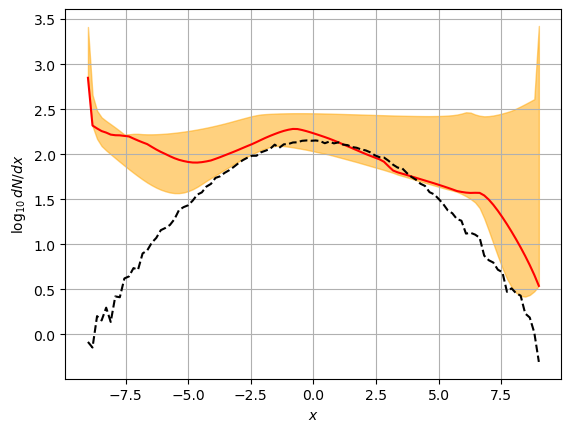

In [110]:
low = np.quantile(log10_dNdx, 0.05, axis=0)
median = np.quantile(log10_dNdx, 0.5, axis=0)
high = np.quantile(log10_dNdx, 0.95, axis=0)

fig, ax = plt.subplots()

ax.set(
    xlabel="$x$",
    ylabel="$\log_{10} dN/dx$",
)
ax.grid()

ax.plot(x_grid, median, color="red")
ax.fill_between(x_grid, low, high, color="orange", alpha=0.5)

ax.plot(x_grid, np.log10(x_rate_gt), color="black", ls="--")

In [111]:
num_triangulations = 200
selected_tris = np.random.choice(len(triangulations), size=num_triangulations, replace=False)

log10_dNdy = np.zeros((num_triangulations, y_grid.shape[0]))

for ind, tri_ind in enumerate(tqdm(selected_tris)):
    this_delo = delaunaytor.CPUDelaunayInterpolator()
    this_delo.triangulate(triangulations[tri_ind])
    log_rate = this_delo.interpolate(grid).reshape(y_grid.shape[0], x_grid.shape[0])
    log10_dNdy[ind] = (special.logsumexp(log_rate, axis=1) + np.log(x_grid[1] - x_grid[0])) / np.log(10)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [00:00<00:00, 533.87it/s]


/tmp/ipykernel_27131/3559612950.py:16: RuntimeWarning: divide by zero encountered in log10
  ax.plot(y_grid, np.log10(y_rate_gt), color="black", ls="--")


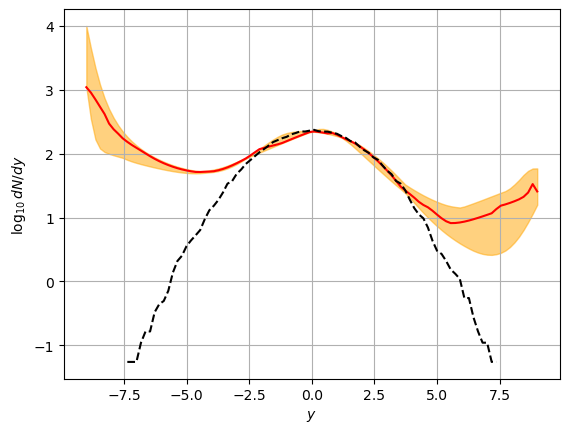

In [112]:
low = np.quantile(log10_dNdy, 0.05, axis=0)
median = np.quantile(log10_dNdy, 0.5, axis=0)
high = np.quantile(log10_dNdy, 0.95, axis=0)

fig, ax = plt.subplots()

ax.set(
    xlabel="$y$",
    ylabel="$\log_{10} dN/dy$",
)
ax.grid()

ax.plot(y_grid, median, color="red")
ax.fill_between(y_grid, low, high, color="orange", alpha=0.5)

ax.plot(y_grid, np.log10(y_rate_gt), color="black", ls="--")